# Data Challenge

In [1]:
from pylab import *
import pandas as pd
from sklearn import preprocessing 
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.utils import resample
import plotly.express as px
import matplotlib.pyplot as plt
import numpy as np

In [6]:
import pandas as pd
import xgboost as xgb

print(f"Version de pandas : {pd.__version__}")
print(f"Version de xgboost : {xgb.__version__}")
print(df.dtypes)

Version de pandas : 2.2.2
Version de xgboost : 2.1.3
load_forecast                    float64
coal_power_available             float64
gas_power_available              float64
nucelear_power_available         float64
wind_power_forecasts_average     float64
solar_power_forecasts_average    float64
wind_power_forecasts_std         float64
solar_power_forecasts_std        float64
predicted_spot_price             float64
dtype: object


Toutes les colonnes sont de type float64. Cependant il y a beaucoup de valeurs manquantes nottament pour spot_price_predicted. Pour les différents modèles de régression ces NaN sont parfois problématiques. 

## Import des data

In [4]:
df = pd.read_csv('X_train_Wwou3IE.csv',sep=',', 
                 parse_dates=['DELIVERY_START'],
                 index_col = 'DELIVERY_START')
df.index = pd.to_datetime(df.index, utc=True)

Y_train = pd.read_csv('y_train_jJtXgMX.csv', 
                      sep =',', 
                      parse_dates=['DELIVERY_START'],
                      index_col = 'DELIVERY_START')
Y_train.index = pd.to_datetime(Y_train.index, utc=True)

X_test = pd.read_csv('X_test_GgyECq8.csv', 
                      sep =',', 
                      parse_dates=['DELIVERY_START'],
                      index_col = 'DELIVERY_START')
X_test.index = pd.to_datetime(X_test.index, utc=True)
df

,load_forecast,coal_power_available,gas_power_available,nucelear_power_available,wind_power_forecasts_average,solar_power_forecasts_average,wind_power_forecasts_std,solar_power_forecasts_std,predicted_spot_price
DELIVERY_START,,,,,,,,,
2022-01-01 01:00:00+00:00,49439.0,3386.0,11487.0,44118.0,3035.0,0.0,79.248348,0.000000,NaN
2022-01-01 02:00:00+00:00,46511.0,3386.0,11487.0,44118.0,3143.0,0.0,61.776532,0.000000,NaN
2022-01-01 03:00:00+00:00,45158.0,3386.0,11487.0,44118.0,3288.0,0.0,44.291112,0.000000,NaN
2022-01-01 04:00:00+00:00,44779.0,3386.0,11487.0,44118.0,3447.0,0.0,36.127588,0.000000,NaN
2022-01-01 05:00:00+00:00,45284.0,3386.0,11487.0,44118.0,3679.0,0.0,30.983023,0.000000,NaN
...,...,...,...,...,...,...,...,...,...
2023-03-29 17:00:00+00:00,50814.0,3386.0,11952.0,38320.0,7552.0,651.0,247.408490,7.821622,108.11
2023-03-29 18:00:00+00:00,50628.0,3386.0,11952.0,38320.0,8338.0,109.0,155.795012,2.534054,125.66
2023-03-29 19:00:00+00:00,48201.0,3386.0,11952.0,38320.0,9115.0,0.0,126.884684,0.000000,138.01


## Analyse des données

### Recherche des liens avec la variables cible

In [435]:
#df['variable_cible']=Y_train['spot_id_delta']
#df['ecart_demande_production']=df['load_forecast']-(df['coal_power_available']+df['gas_power_available']+df['nucelear_power_available']+df['wind_power_forecasts_average']+df['solar_power_forecasts_average'])
#df['production']=df['coal_power_available']+df['gas_power_available']+df['nucelear_power_available']+df['wind_power_forecasts_average']+df['solar_power_forecasts_average']
#df['renewable_energy']=df['wind_power_forecasts_average']+df['solar_power_forecasts_average']
#df['part renouvelable']=(df['wind_power_forecasts_average']+df['solar_power_forecasts_average'])/(df['coal_power_available']+df['gas_power_available']+df['nucelear_power_available']+df['wind_power_forecasts_average']+df['solar_power_forecasts_average'])
#df['demande_passé']=df['load_forecast'].shift(2)
#df['demande_futur']=df['load_forecast'].shift(-2)
#df =df.loc[(df.index >= '2022-11-01') & (df.index <= '2023-02-15')]

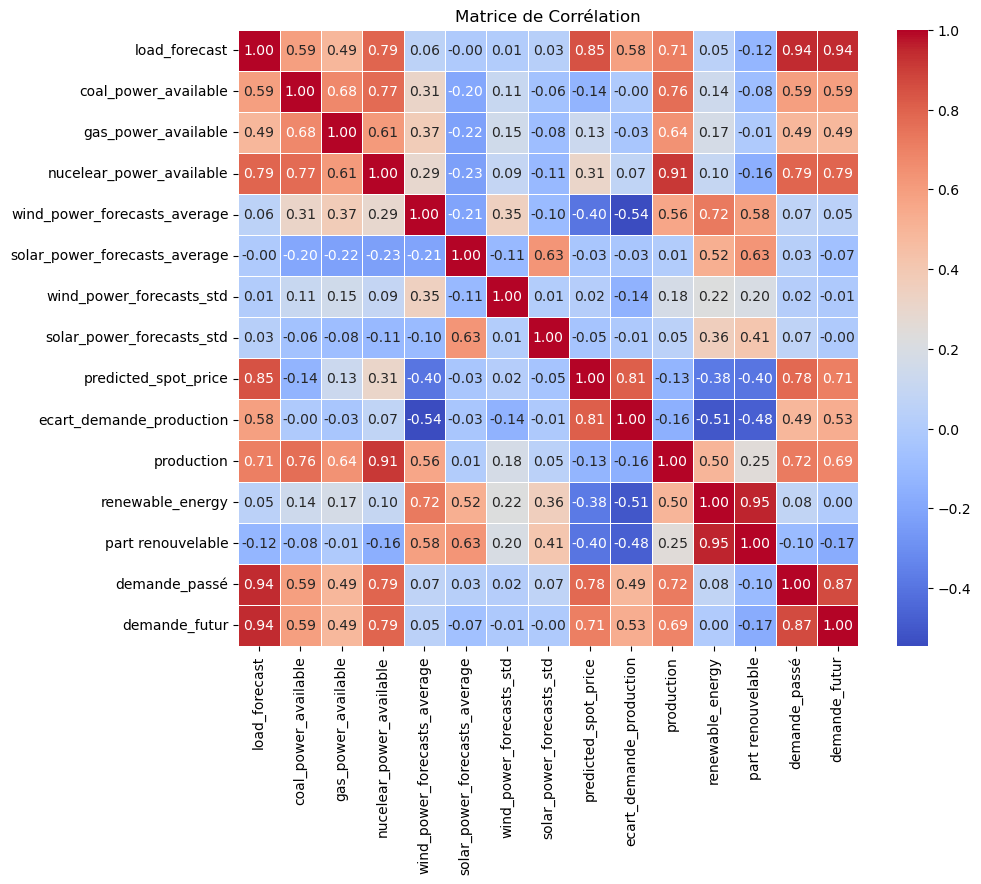

In [437]:
df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matrice de Corrélation")
plt.show()

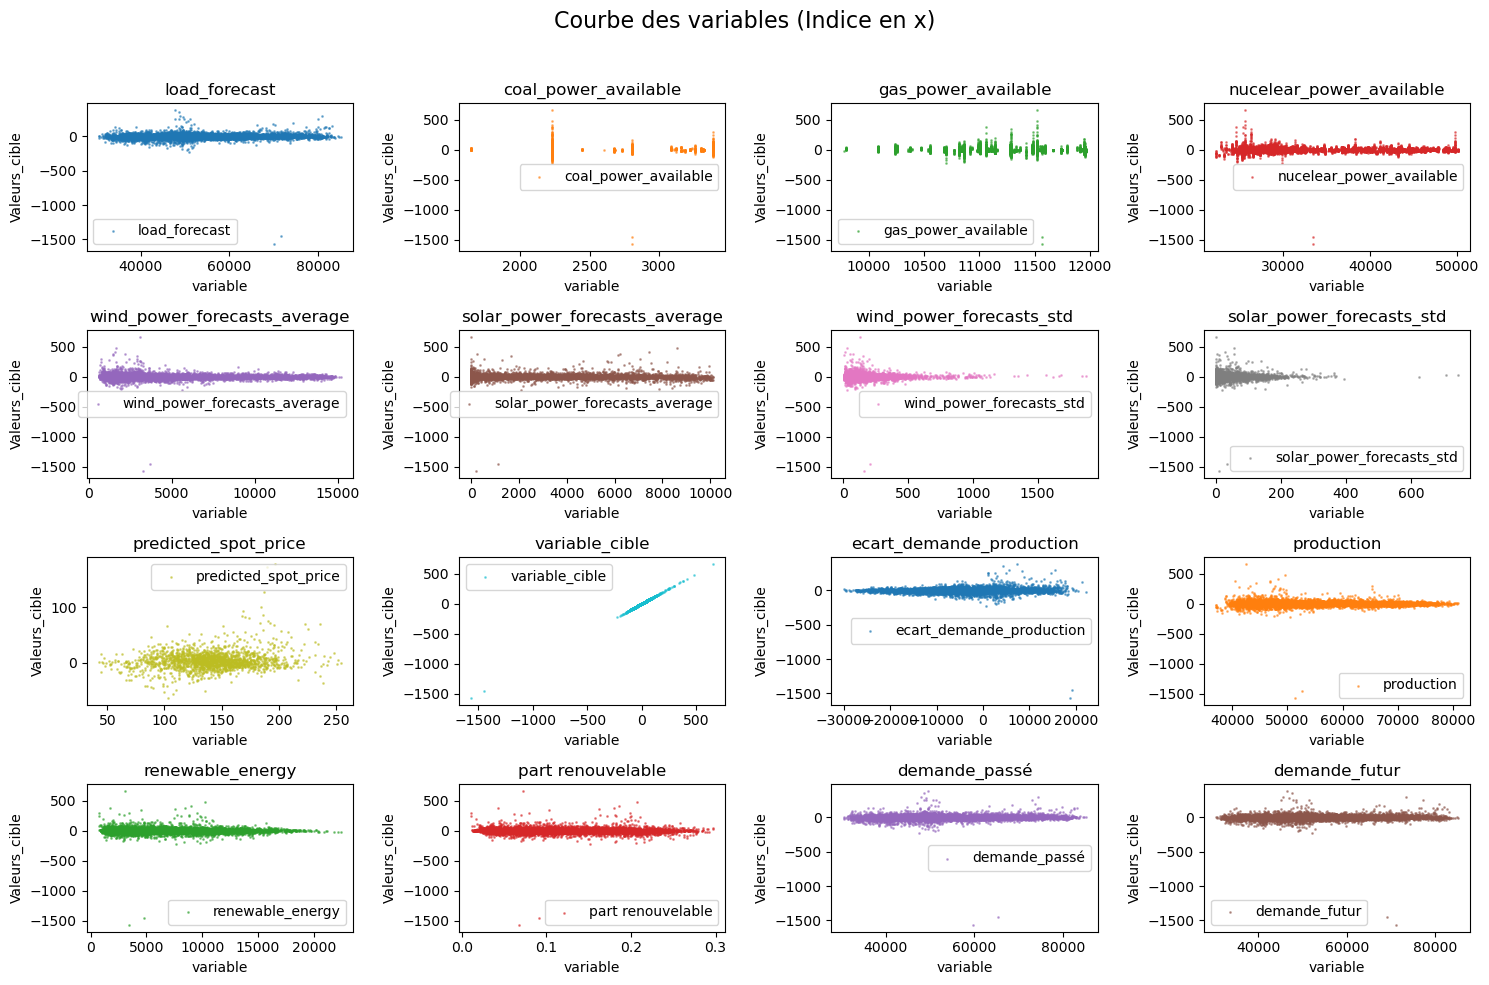

In [284]:
# Liste des colonnes
df_columns = df.columns

# Création d'une grille de subplots
fig, axes = plt.subplots(4, 4, figsize=(15, 10))
fig.suptitle("Courbe des variables (Indice en x)", fontsize=16)

# Boucle sur les colonnes pour tracer les graphiques
for i, col in enumerate(df_columns):
    row, col_idx = divmod(i, 4)  # Calcul des indices de la grille
    ax = axes[row, col_idx]  # Sélectionner l'axe correspondant
    
    # Tracer les courbes avec l'indice comme abscisse
    ax.scatter(df[col],df['variable_cible'], label=col, color=f'C{i}',alpha=0.5,s=1)
    ax.set_title(col)
    ax.set_xlabel("variable")
    ax.set_ylabel("Valeurs_cible")
    ax.legend()

# Supprimer les cases vides (si applicable)
for j in range(len(df_columns), 16):  # 9 = 3x3
    row, col_idx = divmod(j, 4)
    fig.delaxes(axes[row, col_idx])

# Ajustement des espacements
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Laisser de l'espace pour le titre principal
plt.show()


### Modèle de régression sur le predict_spot_price à partir des autres features

On remarque avec le tableau de correlation que le predicted_spot_price est corrélé fortement au load_forecast et dans une moindre mesure au nucléaire et à l'éolien. On va donc établir un modèle de régression pour compléter les valeurs manquantes du predicted_spot_price.

In [505]:
data = df[['predicted_spot_price','load_forecast','nucelear_power_available','wind_power_forecasts_average']]
data_2023 = data.loc[data.index >='2023']
data_2023 = data_2023.dropna()
data_2023

,predicted_spot_price,load_forecast,nucelear_power_available,wind_power_forecasts_average
DELIVERY_START,,,,
2023-01-03 00:00:00+00:00,114.88,48275.0,42390.0,3792.0
2023-01-03 01:00:00+00:00,110.62,47626.0,42390.0,4033.0
2023-01-03 02:00:00+00:00,105.31,45648.0,42390.0,4200.0
2023-01-03 03:00:00+00:00,94.95,44972.0,42390.0,4360.0
2023-01-03 04:00:00+00:00,97.82,47372.0,42390.0,4495.0
...,...,...,...,...
2023-03-29 17:00:00+00:00,108.11,50814.0,38320.0,7552.0
2023-03-29 18:00:00+00:00,125.66,50628.0,38320.0,8338.0
2023-03-29 19:00:00+00:00,138.01,48201.0,38320.0,9115.0


In [528]:
#data_2023_np = data_2023.to_numpy()  
X_features_train = data_2023[['load_forecast','nucelear_power_available','wind_power_forecasts_average']]
Appliances_train = data_2023['predicted_spot_price']

Appliances_train_np = Appliances_train.to_numpy()
X_features_train_np = X_features_train.to_numpy()
X_features_train_np = X_features_train_np.astype(float)
Appliances_train_np = Appliances_train_np.astype(float)
print(Appliances_train_np.dtype)
print(X_features_train_np.dtype)
Appliances_train

float64
float64


DELIVERY_START
2023-01-03 00:00:00+00:00    114.88
2023-01-03 01:00:00+00:00    110.62
2023-01-03 02:00:00+00:00    105.31
2023-01-03 03:00:00+00:00     94.95
2023-01-03 04:00:00+00:00     97.82
                              ...  
2023-03-29 17:00:00+00:00    108.11
2023-03-29 18:00:00+00:00    125.66
2023-03-29 19:00:00+00:00    138.01
2023-03-29 20:00:00+00:00    136.74
2023-03-29 21:00:00+00:00    120.32
Name: predicted_spot_price, Length: 1846, dtype: float64

In [616]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

reg2 = LinearRegression(); 
reg2.fit(X_features_train_np,Appliances_train_np);
reg2.score(X_features_train_np,Appliances_train_np)

reg3 = RandomForestRegressor(n_estimators=10);
reg3.fit(X_features_train, Appliances_train)
reg3.score(X_features_train, Appliances_train)

0.9610146880661644

On obtient un score de 0,734 avec la régression linéaire. Cependant on obtient un score d'environ 0,95 pour un randomForestRegressor. On va donc essayé de compléter les colonnes manquantes avec le modèle obtenu. 

In [630]:
y_spot = reg3.predict(df[['load_forecast','nucelear_power_available','wind_power_forecasts_average']])
y_spot = pd.DataFrame(y_spot,columns=['predicted_spot_price'])
df = pd.read_csv('X_train_Wwou3IE.csv',sep=',')
y_spot['DELIVERY_START']= df['DELIVERY_START']
y_spot.set_index('DELIVERY_START', inplace=True)
y_spot.index = pd.to_datetime(y_spot.index, utc=True)

In [632]:
df = pd.read_csv('X_train_Wwou3IE.csv',sep=',', 
                 parse_dates=['DELIVERY_START'],
                 index_col = 'DELIVERY_START')
df.index = pd.to_datetime(df.index, utc=True)

In [634]:
df['predicted_spot_price']=y_spot['predicted_spot_price']
df

,load_forecast,coal_power_available,gas_power_available,nucelear_power_available,wind_power_forecasts_average,solar_power_forecasts_average,wind_power_forecasts_std,solar_power_forecasts_std,predicted_spot_price
DELIVERY_START,,,,,,,,,
2022-01-01 01:00:00+00:00,49439.0,3386.0,11487.0,44118.0,3035.0,0.0,79.248348,0.000000,114.532
2022-01-01 02:00:00+00:00,46511.0,3386.0,11487.0,44118.0,3143.0,0.0,61.776532,0.000000,104.891
2022-01-01 03:00:00+00:00,45158.0,3386.0,11487.0,44118.0,3288.0,0.0,44.291112,0.000000,99.404
2022-01-01 04:00:00+00:00,44779.0,3386.0,11487.0,44118.0,3447.0,0.0,36.127588,0.000000,96.630
2022-01-01 05:00:00+00:00,45284.0,3386.0,11487.0,44118.0,3679.0,0.0,30.983023,0.000000,99.415
...,...,...,...,...,...,...,...,...,...
2023-03-29 17:00:00+00:00,50814.0,3386.0,11952.0,38320.0,7552.0,651.0,247.408490,7.821622,111.563
2023-03-29 18:00:00+00:00,50628.0,3386.0,11952.0,38320.0,8338.0,109.0,155.795012,2.534054,123.543
2023-03-29 19:00:00+00:00,48201.0,3386.0,11952.0,38320.0,9115.0,0.0,126.884684,0.000000,125.696


# Modèle de Classification

Pour la classification, on ne va pas se préocuper de l'écart mais seulement du prix le plus élevé entre les 2 marchés. Si le prix SPOT est plus élevé alors on assigne la valeur 0 et si le prix sur le marché intra-journalier est supérieur alors on assigne la valeur 1. On se ramène donc à un problème de classification supervisée à 2 classes. 

In [14]:
Y_train['Ecart_de_prix'] = Y_train['spot_id_delta'].apply(lambda x: 1 if x > 0 else -1)
Y_train_c = Y_train['Ecart_de_prix']
Y_train_c

DELIVERY_START
2022-01-01 01:00:00+00:00   -1
2022-01-01 02:00:00+00:00   -1
2022-01-01 03:00:00+00:00   -1
2022-01-01 04:00:00+00:00    1
2022-01-01 05:00:00+00:00    1
                            ..
2023-03-29 17:00:00+00:00    1
2023-03-29 18:00:00+00:00    1
2023-03-29 19:00:00+00:00    1
2023-03-29 20:00:00+00:00    1
2023-03-29 21:00:00+00:00    1
Name: Ecart_de_prix, Length: 10605, dtype: int64

## Validation croisée

In [18]:
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [10, 20],
}

In [28]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test, mag_train, mag_test = train_test_split(df, Y_train_c, Y_train_r, test_size=0.2, random_state=42)

In [30]:

y_train_np = y_train.to_numpy()
y_train_npr = y_train_np.ravel()


my_kfold = KFold(n_splits=5, shuffle=True,random_state=0)
Cart_grid = GridSearchCV(estimator = RandomForestClassifier(),
                      param_grid = param_grid,
                      cv=my_kfold,
                      verbose=1,             # Affiche la progression
                      error_score='raise')


Cart_grid.fit(x_train,y_train_npr)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


GridSearchCV(cv=KFold(n_splits=5, random_state=0, shuffle=True),
             error_score='raise', estimator=RandomForestClassifier(),
             param_grid={'max_depth': [10, 20],
                         'n_estimators': [50, 100, 200, 300]},
             verbose=1)

## Methode RFECV

In [66]:
from sklearn.feature_selection import RFECV
best_model = Cart_grid.best_estimator_
rfecv = RFECV(
    estimator=best_model,
    step=1,  # Nombre de caractéristiques à supprimer à chaque itération
    cv=my_kfold,  # Nombre de plis pour la validation croisée
    scoring="accuracy",  # Métrique d'évaluation
    min_features_to_select=5,  # Nombre minimal de caractéristiques à conserver
    verbose=2
)
rfecv.fit(x_train, y_train_npr)

Fitting estimator with 9 features.
Fitting estimator with 8 features.
Fitting estimator with 7 features.
Fitting estimator with 6 features.
Fitting estimator with 9 features.
Fitting estimator with 8 features.
Fitting estimator with 7 features.
Fitting estimator with 6 features.
Fitting estimator with 9 features.
Fitting estimator with 8 features.
Fitting estimator with 7 features.


KeyboardInterrupt: 

On ne garde que les features que la méthode RFECV dit de garder. En relançant le système ca ne marche pas donc on va prendre les variables qui nous semblent être les plus pertinentes. 

In [414]:
# Résultats de RFECV
print(f"Nombre optimal de caractéristiques : {rfecv.n_features_}")
print(f"Caractéristiques sélectionnées : {rfecv.support_}")

Nombre optimal de caractéristiques : 4
Caractéristiques sélectionnées : [ True False  True False  True False False False False  True False False
 False False False False]


D'après le modèle, on ne conserve que load_forecast, gas_power_available, wind_power_forecasts_average	et predicted_spot_price. On réalise maintenant la classification à partir de ces 4 features et des hyperparamètres optimaux.  

### Classification avec RandomForest

In [680]:
#x_train_selected = rfecv.transform(x_train)
#x_test_selected = rfecv.transform(x_test)

x_train_selected = x_train[['load_forecast', 'gas_power_available', 'wind_power_forecasts_average', 'predicted_spot_price']]
x_test_selected = x_test[['load_forecast', 'gas_power_available', 'wind_power_forecasts_average', 'predicted_spot_price']]

best_model.fit(x_train_selected, y_train)
accuracy = best_model.score(x_test_selected, y_test)
accuracy

0.6430928807166431

On obtient un score de 0.63 pour la classification en utilisant RandomForrest. On est au-dessus des 0.52 que l'on obtenait en ne séparant pas les modèles.

## Pondération du modèle de classification

In [11]:
Y_train['Ecart_de_prix'] = Y_train['spot_id_delta'].abs() # on ne prend que la valeur absolue. 
Y_train_r = Y_train['Ecart_de_prix']
Y_train_r

DELIVERY_START
2022-01-01 01:00:00+00:00    36.874770
2022-01-01 02:00:00+00:00    12.643588
2022-01-01 03:00:00+00:00     1.950193
2022-01-01 04:00:00+00:00     1.938272
2022-01-01 05:00:00+00:00     0.199907
                               ...    
2023-03-29 17:00:00+00:00     6.029303
2023-03-29 18:00:00+00:00    13.576177
2023-03-29 19:00:00+00:00    17.478945
2023-03-29 20:00:00+00:00    17.559407
2023-03-29 21:00:00+00:00    16.503259
Name: Ecart_de_prix, Length: 10605, dtype: float64

In [32]:
best_model = Cart_grid.best_estimator_

In [81]:
from sklearn.model_selection import train_test_split


# RandomForest avec pondération par échantillon
best_model = RandomForestClassifier(max_depth=10, n_estimators=200,random_state=42)


x_train_selected = x_train[['load_forecast', 'gas_power_available', 'wind_power_forecasts_average', 'predicted_spot_price']]
x_test_selected = x_test[['load_forecast', 'gas_power_available', 'wind_power_forecasts_average', 'predicted_spot_price']]


best_model.fit(x_train_selected, y_train, sample_weight=mag_train)  # Pondération par la magnitude des écarts
accuracy = best_model.score(x_test_selected, y_test)
accuracy


0.6204620462046204

In [83]:
X_test_selected = X_test[['load_forecast', 'gas_power_available', 'wind_power_forecasts_average', 'predicted_spot_price']]

In [85]:
# Prédictions
y_pred = best_model.predict(X_test_selected)
y_pred

array([ 1,  1,  1, ...,  1,  1, -1], dtype=int64)

On obtient un moins bon score que précédemment (0,51). Le modèle est peut-être trop fit avec les données train. Si l'on sélectionne que les 4 variables au lieu de prendre l'ensemble des variables, on obtient un score de 0,54. On a donc amélioré le modèle. 

# Modèle de Régression

Pour le modèle de régression, on ne va s'intéresser qu'à la différence en valeurs absolue entre les prix. On va inclure la prediction trouvé dans le modèle de classification pour limiter les erreurs de classifcation

In [707]:
Y_train['Ecart_de_prix'] = Y_train['spot_id_delta'].abs() # on ne prend que la valeur absolue. 
Y_train_r = Y_train['Ecart_de_prix']
Y_train

,spot_id_delta,Ecart_de_prix
DELIVERY_START,,
2022-01-01 01:00:00+00:00,-36.874770,36.874770
2022-01-01 02:00:00+00:00,-12.643588,12.643588
2022-01-01 03:00:00+00:00,-1.950193,1.950193
2022-01-01 04:00:00+00:00,1.938272,1.938272
2022-01-01 05:00:00+00:00,0.199907,0.199907
...,...,...
2023-03-29 17:00:00+00:00,6.029303,6.029303
2023-03-29 18:00:00+00:00,13.576177,13.576177
2023-03-29 19:00:00+00:00,17.478945,17.478945


On ajoute à X_train la prédiction du signe de Y_test pour inclure les potentiels erreurs de la classification dans le modèle de régression. 

In [684]:
df['signe_diff_prix']=best_model.predict(df[['load_forecast', 'gas_power_available', 'wind_power_forecasts_average', 'predicted_spot_price']])
df

,load_forecast,coal_power_available,gas_power_available,nucelear_power_available,wind_power_forecasts_average,solar_power_forecasts_average,wind_power_forecasts_std,solar_power_forecasts_std,predicted_spot_price,signe_diff_prix
DELIVERY_START,,,,,,,,,,
2022-01-01 01:00:00+00:00,49439.0,3386.0,11487.0,44118.0,3035.0,0.0,79.248348,0.000000,NaN,-1
2022-01-01 02:00:00+00:00,46511.0,3386.0,11487.0,44118.0,3143.0,0.0,61.776532,0.000000,NaN,-1
2022-01-01 03:00:00+00:00,45158.0,3386.0,11487.0,44118.0,3288.0,0.0,44.291112,0.000000,NaN,-1
2022-01-01 04:00:00+00:00,44779.0,3386.0,11487.0,44118.0,3447.0,0.0,36.127588,0.000000,NaN,-1
2022-01-01 05:00:00+00:00,45284.0,3386.0,11487.0,44118.0,3679.0,0.0,30.983023,0.000000,NaN,1
...,...,...,...,...,...,...,...,...,...,...
2023-03-29 17:00:00+00:00,50814.0,3386.0,11952.0,38320.0,7552.0,651.0,247.408490,7.821622,108.11,1
2023-03-29 18:00:00+00:00,50628.0,3386.0,11952.0,38320.0,8338.0,109.0,155.795012,2.534054,125.66,1
2023-03-29 19:00:00+00:00,48201.0,3386.0,11952.0,38320.0,9115.0,0.0,126.884684,0.000000,138.01,1


## Validation croisée

In [555]:
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    'n_estimators': [50, 100, 200, 300, 500],
    'max_depth': [10, 20, 30],
}

In [686]:
from sklearn.model_selection import train_test_split

x_train_r, x_test_r, y_train_r, y_test_r = train_test_split(df, Y_train_r, test_size=0.2, random_state=42)

In [559]:

y_train_npr = y_train_r.to_numpy()
y_train_nprr = y_train_npr.ravel()


my_kfold = KFold(n_splits=5, shuffle=True,random_state=0)
Cart_grid_r = GridSearchCV(estimator = RandomForestRegressor(),
                      param_grid = param_grid,
                      cv=my_kfold,
                      verbose=1,             # Affiche la progression
                      error_score='raise')


Cart_grid_r.fit(x_train_r,y_train_nprr)

Fitting 5 folds for each of 15 candidates, totalling 75 fits


GridSearchCV(cv=KFold(n_splits=5, random_state=0, shuffle=True),
             error_score='raise', estimator=RandomForestRegressor(),
             param_grid={'max_depth': [10, 20, 30],
                         'n_estimators': [50, 100, 200, 300, 500]},
             verbose=1)

## Méthode RFECV

In [568]:
from sklearn.feature_selection import RFECV
best_model_r = Cart_grid_r.best_estimator_
rfecv_r = RFECV(
    estimator=best_model_r,
    step=1,  # Nombre de caractéristiques à supprimer à chaque itération
    cv=my_kfold,  # Nombre de plis pour la validation croisée
    scoring="r2",  # Métrique d'évaluation
    min_features_to_select=5,  # Nombre minimal de caractéristiques à conserver
    verbose=1
)
rfecv_r.fit(x_train_r, y_train_nprr)

Fitting estimator with 10 features.
Fitting estimator with 9 features.
Fitting estimator with 8 features.
Fitting estimator with 7 features.
Fitting estimator with 6 features.
Fitting estimator with 10 features.
Fitting estimator with 9 features.
Fitting estimator with 8 features.


KeyboardInterrupt: 

In [ ]:
 Résultats de RFECV
print(f"Nombre optimal de caractéristiques : {rfecv_r.n_features_}")
print(f"Caractéristiques sélectionnées : {rfecv_r.support_}")



## Regression avec RandomForrest

In [688]:
#x_train_selected_r = rfecv.transform(x_train_r)
#x_test_selected_r = rfecv.transform(x_test_r)

best_model_r.fit(x_train_r, y_train_r)
accuracy_r = best_model_r.score(x_test_r, y_test_r)
accuracy_r

0.507621996483923

# Combinaison des 2 modèles

### Resultat de la classification sur X_test

In [690]:
Y_classification = best_model.predict(X_test[['load_forecast', 'gas_power_available', 'wind_power_forecasts_average', 'predicted_spot_price']])
Y_classification

array([ 1,  1,  1, ..., -1, -1, -1], dtype=int64)

###  Resultat de la régression sur X_test 

In [693]:
X_test['signe_diff_prix']=Y_classification
Y_regression = best_model_r.predict(X_test)
Y_regression

array([13.38143573, 12.64048138, 12.02072759, ...,  9.63692896,
       12.54258889, 15.90916144])

In [695]:
Y_final = Y_classification * Y_regression
Y_final

array([ 13.38143573,  12.64048138,  12.02072759, ...,  -9.63692896,
       -12.54258889, -15.90916144])

In [697]:
X_test

,load_forecast,coal_power_available,gas_power_available,nucelear_power_available,wind_power_forecasts_average,solar_power_forecasts_average,wind_power_forecasts_std,solar_power_forecasts_std,predicted_spot_price,signe_diff_prix
DELIVERY_START,,,,,,,,,,
2023-04-01 22:00:00+00:00,45814.0,3386.0,10902.0,36705.0,6359.0,0.0,56.764535,0.0,NaN,1
2023-04-01 23:00:00+00:00,44084.0,3386.0,10902.0,36705.0,6469.0,0.0,54.262133,0.0,NaN,1
2023-04-02 00:00:00+00:00,43281.0,3386.0,10902.0,36705.0,6511.0,0.0,78.105928,0.0,NaN,1
2023-04-02 01:00:00+00:00,40825.0,3386.0,10902.0,36705.0,6628.0,0.0,78.187557,0.0,NaN,1
2023-04-02 02:00:00+00:00,39181.0,3386.0,10902.0,36705.0,6700.0,0.0,96.765484,0.0,NaN,1
...,...,...,...,...,...,...,...,...,...,...
2023-10-24 17:00:00+00:00,49686.0,2226.0,11749.0,42980.0,4901.0,0.0,247.887323,0.0,125.67,1
2023-10-24 18:00:00+00:00,53397.0,2226.0,11749.0,42980.0,5584.0,0.0,343.192642,0.0,139.58,-1
2023-10-24 19:00:00+00:00,50586.0,2226.0,11749.0,42980.0,6306.0,0.0,471.875973,0.0,147.93,-1


In [88]:
Y_test_csv = pd.DataFrame(y_pred,columns=['spot_id_delta'])
Y_test_csv

,spot_id_delta
0,1
1,1
2,1
3,1
4,1
...,...
4937,1
4938,1
4939,1
4940,1


In [91]:
X_test = pd.read_csv('X_test_GgyECq8.csv', 
                      sep =',')
Y_test_csv['DELIVERY_START']= X_test['DELIVERY_START']
Y_test_csv.set_index('DELIVERY_START', inplace=True)

Y_test_csv.to_csv('Y_test_1.csv', sep=',', index=True)
Y_test_csv

,spot_id_delta
DELIVERY_START,
2023-04-02 00:00:00+02:00,1
2023-04-02 01:00:00+02:00,1
2023-04-02 02:00:00+02:00,1
2023-04-02 03:00:00+02:00,1
2023-04-02 04:00:00+02:00,1
...,...
2023-10-24 19:00:00+02:00,1
2023-10-24 20:00:00+02:00,1
2023-10-24 21:00:00+02:00,1


a l'aide de la regression sur le predicted_spot_price, on obtient un score moins bon. 

## Methode XGBoost

In [574]:
from sklearn.model_selection import train_test_split
import xgboost as xgb
from xgboost import XGBRegressor

### Validation croisée 

In [577]:
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV

#### Les hyperparamètres

In [90]:
my_kfold = KFold(n_splits=5, shuffle=True,random_state=0)
tree_range = list(range(10,50,2)) + list(range(55,100,5))+ list(range(110,200,10))
param_grid = {
    'n_estimators': tree_range,       # Nombre d'arbres
    #'learning_rate': [0.01, 0.1, 0.2],   # Taux d'apprentissage
    'max_depth': [3,6],              # Profondeur maximale
    
}


# Configuration de GridSearchCV
boost_grid = GridSearchCV(
    estimator=xgb.XGBRegressor(objective='reg:squarederror', random_state=42),
    param_grid=param_grid,
    scoring='r2',          # Métrique utilisée pour évaluer le modèle
    cv=my_kfold,           # Validation croisée kfold
    verbose=1,             # Affiche la progression
    error_score='raise'
)
boost_grid.fit(df,Y_train)

In [ ]:
boost_grid.best_estimator_

### Le modèle de régression XGBoost

In [579]:
import xgboost as xgb
print(xgb.__version__)

x_train_r, x_test_r, y_train_r, y_test_r = train_test_split(df, Y_train_r, test_size=0.2, random_state=42)

clf = xgb.XGBRegressor(tree_method="hist", max_depth=6, n_estimators=190, eta=0.2)
# Fit the model, test sets are used for early stopping.
clf.fit(x_train_r, y_train_r, eval_set=[(x_test_r, y_test_r)])
clf.score(x_test_r, y_test_r)

AttributeError: module 'pandas' has no attribute 'util'

## Random Forrest

In [376]:
from sklearn.ensemble import RandomForestRegressor 
from sklearn.model_selection import train_test_split

### Validation croisée

In [379]:
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV

### RF_Grid

In [705]:
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV

my_kfold = KFold(n_splits=5, shuffle=True,random_state=0) 

tree_range = list(range(10,50,2)) + list(range(55,100,5))+ list(range(110,200,10))

tuned_parameters = {'n_estimators': tree_range}

RF_grid = GridSearchCV(
    estimator = RandomForestRegressor(max_features=9),
    param_grid = tuned_parameters,
    cv=my_kfold,
    n_jobs=-1)

RF_grid.fit(x_train, y_train)

KeyboardInterrupt: 

### Le modèle de régression RandomForest

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(df, Y_train, random_state=46)

clf = RandomForestRegressor(tree_method="hist", max_depth=6, n_estimators=190)
# Fit the model, test sets are used for early stopping.
clf.fit(x_train, y_train, eval_set=[(x_test, y_test)])
clf.score(x_test, y_test)

## Bagging Regressor

In [ ]:
from sklearn.ensemble import BaggingRegressor

X_test_1 = X_test.drop('predicted_spot_price', axis=1)

x_train, x_test, y_train, y_test = train_test_split(df_1, Y_train, test_size=0.2, random_state=42)
bagTree = BaggingRegressor(n_estimators=20)
bagTree.fit(x_train,y_train)
Y_test_1 = bagTree.predict(X_test_1)
bagTree.score(x_test, y_test)

# Weighted accuracy

In [ ]:
from sklearn.metrics import mean_absolute_error

def weighted_accuracy(y_true, y_pred):
    """
    Calcule la Weighted Accuracy :
    - Proportion des prédictions dont les signes sont correctement identifiés.
    - Pondérée par la valeur absolue des écarts réellement observés.
    
    Arguments :
    - y_true : np.array, valeurs réelles.
    - y_pred : np.array, prédictions du modèle.
    
    Retourne :
    - float : Weighted Accuracy.
    """
    # Calcul des erreurs absolues
    errors = np.abs(y_true - y_pred)
    
    # Déterminer si les signes sont corrects
    sign_correct = (np.sign(y_true) == np.sign(y_pred)).astype(int)
    
    # Weighted Accuracy
    weighted_accuracy = np.sum(sign_correct * errors) / np.sum(errors)
    
    return weighted_accuracy
df_2023= df.loc[(df.index >= '2023-01-01') & (df.index <= '2023-01-30')]
# Liste des colonnes
df_columns = df_2023.columns

# Création d'une grille de subplots
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
fig.suptitle("Courbe des variables (Indice en x)", fontsize=16)

# Boucle sur les colonnes pour tracer les graphiques
for i, col in enumerate(df_columns):
    row, col_idx = divmod(i, 3)  # Calcul des indices de la grille
    ax = axes[row, col_idx]  # Sélectionner l'axe correspondant
    
    # Tracer les courbes avec l'indice comme abscisse
    ax.plot(df_2023.index, df_2023[col], label=col, color=f'C{i}')
    ax.set_title(col)
    ax.set_xlabel("date")
    ax.set_ylabel("Valeurs")
    ax.legend()

# Supprimer les cases vides (si applicable)
for j in range(len(df_columns), 9):  # 9 = 3x3
    row, col_idx = divmod(j, 3)
    fig.delaxes(axes[row, col_idx])

# Ajustement des espacements
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Laisser de l'espace pour le titre principal
plt.show()